In [6]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
import statsmodels.api as sm
from functions_fcsuml import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)



In [7]:
blobs, labels, centers = datasets.make_blobs(n_samples=90000, n_features=100, centers=200, random_state=42, return_centers=True)

targets = blobs[:, -1]
data = blobs[:, :-1]
print(data.shape, targets.shape)

(90000, 99) (90000,)


In [8]:
training_data, testing_data, training_targets, testing_targets = train_test_split(data, targets, test_size=0.2, random_state=42)

testing_data, validation_data, testing_targets, validation_targets = train_test_split(testing_data, testing_targets, test_size=0.5, random_state=42)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)
print('X3 shape: ', validation_data.shape)
print('X4 shape: ', training_targets.shape)
print('X5 shape: ', testing_targets.shape)
print('X6 shape: ', validation_targets.shape)

# Normalizing the data
norm_data, normalization_variables = normalize(training_data)
norm_targets, max_targets, min_targets = normalize_feature(training_targets)

norm_testing_targets = (testing_targets-min_targets)/(max_targets-min_targets)
norm_validation_targets = (validation_targets-min_targets)/(max_targets-min_targets)
norm_validation_data = (validation_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
norm_testing_data = (testing_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
print(np.shape(norm_data))

X1 shape:  (72000, 99)
X2 shape:  (9000, 99)
X3 shape:  (9000, 99)
X4 shape:  (72000,)
X5 shape:  (9000,)
X6 shape:  (9000,)
(72000, 99)


# Raw data

In [9]:
X_norm_data = sm.add_constant(norm_data)

model_sm = sm.OLS(norm_targets, X_norm_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     576.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:40:07   Log-Likelihood:                 23451.
No. Observations:               72000   AIC:                        -4.670e+04
Df Residuals:                   71900   BIC:                        -4.578e+04
Df Model:                          99                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2920      0.023     12.511      0.0

# Embedded data

[    0.     0.   374.   735.  1086.  1435.  1798.  2163.  2505.  2857.
  3217.  3587.  3956.  4306.  4675.  5038.  5384.  5756.  6119.  6468.
  6828.  7195.  7537.  7894.  8260.  8613.  8986.  9344.  9703. 10077.
 10438. 10796. 11153. 11517. 11873. 12239. 12608. 12964. 13332. 13688.
 14026. 14387. 14745. 15095. 15473. 15837. 16210. 16589. 16940. 17305.
 17660. 18027. 18394. 18749. 19106. 19457. 19819. 20176. 20526. 20884.
 21244. 21599. 21974. 22328. 22683. 23051. 23410. 23780. 24123. 24482.
 24842. 25210. 25565. 25920. 26292. 26654. 27020. 27383. 27749. 28111.
 28476. 28840. 29195. 29559. 29909. 30257. 30621. 30985. 31350. 31713.
 32084. 32436. 32795. 33155. 33517. 33887. 34251. 34600. 34949. 35303.
 35669. 36031. 36399. 36750. 37114. 37481. 37842. 38202. 38561. 38899.
 39254. 39611. 39980. 40344. 40706. 41064. 41430. 41795. 42155. 42508.
 42863. 43220. 43583. 43955. 44324. 44687. 45039. 45404. 45775. 46142.
 46497. 46863. 47212. 47584. 47941. 48314. 48674. 49033. 49380. 49743.
 50106

/Users/davidbaaw/code/Exjobb/functions_fcsuml.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


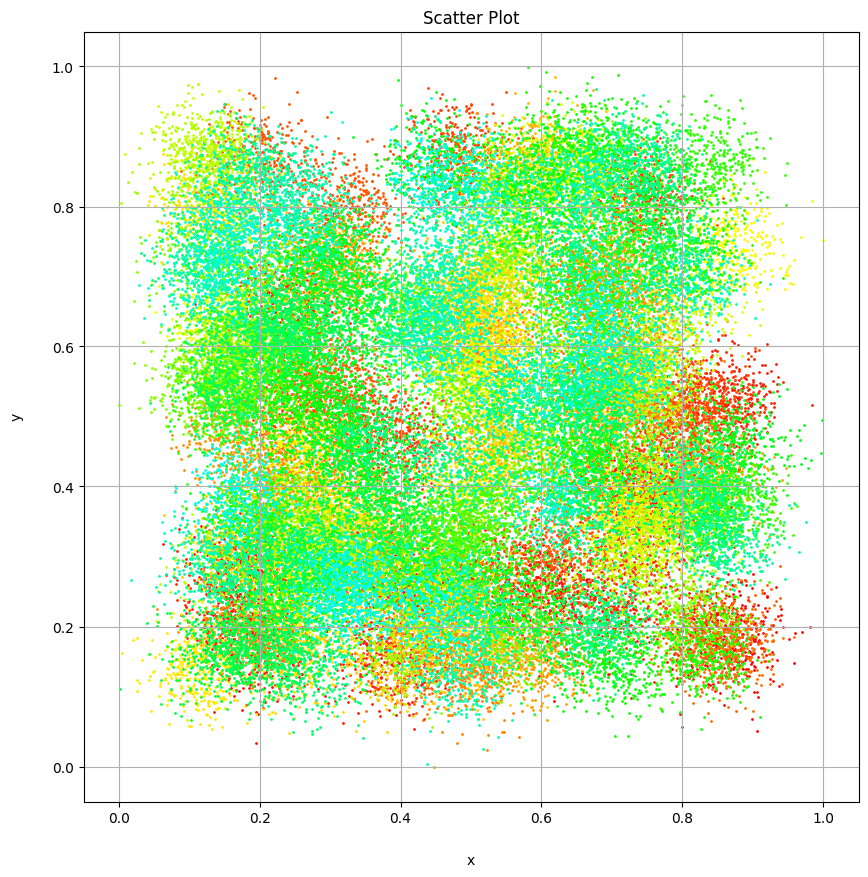

In [11]:
number_of_clusters, optimal_clustering = clustering(norm_data, cluster_size=100, min_samples=2)

sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:, 0] += 1
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [12]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    # print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        # print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

[[1.00000000e+00 1.85110506e-01 8.64143809e-01 ... 7.72805491e-01
  3.58529542e-01 8.23083545e-01]
 [2.00000000e+00 2.48713087e-01 6.10761619e-01 ... 8.10157377e-01
  1.49320501e-01 6.98407579e-01]
 [3.00000000e+00 2.65046683e-01 3.93516498e-01 ... 1.49931732e-01
  8.12606201e-01 6.36531169e-01]
 ...
 [1.98000000e+02 2.62641711e-01 3.30585361e-01 ... 5.06535768e-01
  5.74571613e-01 3.45728980e-01]
 [1.99000000e+02 2.51298172e-01 3.12015819e-01 ... 2.02462689e-01
  4.20896694e-01 2.72600621e-01]
 [2.00000000e+02 2.31883285e-01 4.48166885e-01 ... 2.23862463e-01
  8.04791347e-01 6.30621004e-01]]
(72000, 200)


In [13]:
embedded_testing_data = (transformation_matrix@norm_testing_data.T).T
X_embedded_data = sm.add_constant(embedded_data)

model_sm = sm.OLS(norm_targets, X_embedded_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     576.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:04:35   Log-Likelihood:                 23451.
No. Observations:               72000   AIC:                        -4.670e+04
Df Residuals:                   71900   BIC:                        -4.578e+04
Df Model:                          99                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2920      0.023     12.511      0.0

# PCA

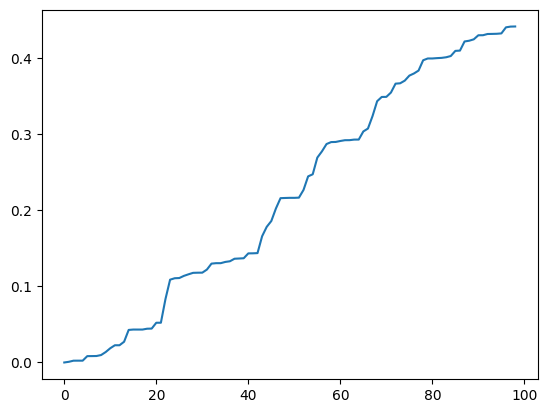

In [14]:
max_n_components = norm_data.shape[1]
r2_mat = np.zeros(max_n_components)

for n in range(max_n_components):
    pca = PCA(n_components=n)
    pca.fit(norm_data)

    pca_embed = pca.fit_transform(norm_data)
    # print(pca_embed.shape)
    # print(pca.explained_variance_ratio_)
    # print(pca.singular_values_)
    

    pca_embedded_data = sm.add_constant(pca_embed)

    pca_model_sm = sm.OLS(norm_targets, pca_embedded_data)
    pca_results_sm = pca_model_sm.fit()
    r2_mat[n] = pca_results_sm.rsquared_adj

plt.plot(r2_mat)


In [20]:
pca = PCA(n_components=96) # last significant change at 96
pca.fit(norm_data)

pca_embed = pca.fit_transform(norm_data)
print(pca_embed.shape)
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)


pca_embedded_data = sm.add_constant(pca_embed)

pca_model_sm = sm.OLS(norm_targets, pca_embedded_data)
pca_results_sm = pca_model_sm.fit()

print(pca_results_sm.summary())

(72000, 96)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     591.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:13:00   Log-Likelihood:                 23376.
No. Observations:               72000   AIC:                        -4.656e+04
Df Residuals:                   71903   BIC:                        -4.567e+04
Df Model:                          96                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4946      0.001    758.